In [54]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [55]:
# logistic regression for imbalanced dataset

In [56]:
# to make the imbalanced dataset we use the make_classificatoin with the weights = [0.99] which menas 
# out of one class on of the class has 99 percent of the same vlaues

In [57]:
from sklearn.datasets import make_classification
from collections import Counter

In [58]:
# create dataset
X, y = make_classification(n_samples=10000, n_features=20, n_classes=2,weights=[0.99], random_state=42)

In [59]:
X.shape

(10000, 20)

In [60]:
X

array([[-0.70029661,  0.31374384,  1.19535267, ...,  1.60033929,
         0.77295496,  1.80359292],
       [ 1.26520125,  1.80551062, -1.00719561, ...,  0.55370642,
         0.72971507,  0.97587135],
       [-1.42082237, -0.90580586, -1.09393816, ...,  1.27031736,
         0.99399274,  0.90635371],
       ...,
       [-1.30993779, -1.601322  , -0.72688671, ..., -0.91066085,
        -0.98393053, -0.5319741 ],
       [-0.80128614, -0.46487862,  1.20373667, ..., -0.69189211,
         0.17473731,  0.59317852],
       [-0.24921179, -0.68844774, -0.5840946 , ..., -0.9221052 ,
         0.69061415, -0.78624774]])

In [61]:
y.shape

(10000,)

In [62]:
# use counter to check the imbalance 
Counter(y)

Counter({np.int64(0): 9856, np.int64(1): 144})

<Axes: xlabel='10', ylabel='11'>

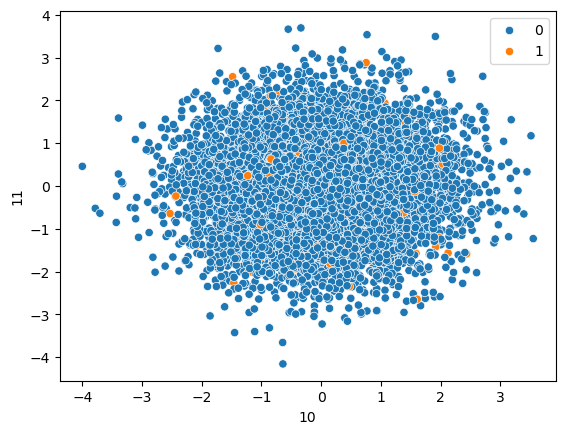

In [63]:
# jsut visualize the x values in the two axis so just take the two col values by converting it into the dataframe

df = pd.DataFrame(X)
sns.scatterplot(x=df[10], y=df[11], hue=y)

In [64]:
# aobve graph shwos imbalanced dataset

In [65]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [66]:
# while doing hyperparamerter tuning as this data is imbalanced so use the class_weight 

In [67]:
## Hyperparamter tuning
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [68]:
params=dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)

In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)

In [74]:
grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [76]:
grid.fit(X_train,y_train)

D:\anaconda\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
D:\anaconda\Lib\

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [77]:
grid.best_params_

{'C': 100,
 'class_weight': {0: 10, 1: 1},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [78]:
grid.best_score_


np.float64(0.98525)

In [ ]:
#  Logistic Regression ROC
# why we are learning this
# iin normal logistic the threshold is 0.5, if prov is <0.5 it make it zero and gt>0.5 make it one
# so in order to change the threshold we use this roc